## Calculating CARs

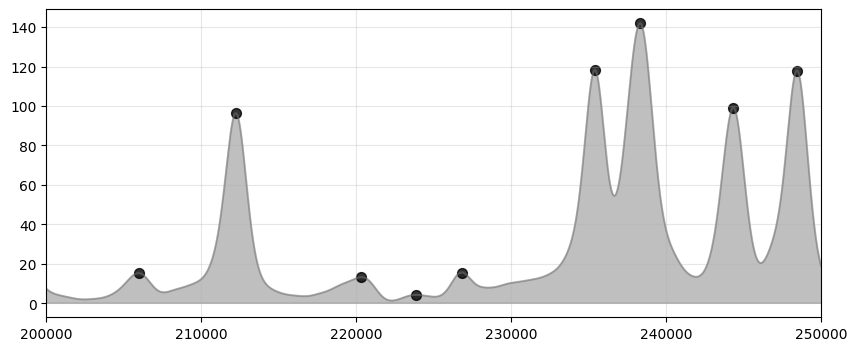

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bio
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
%matplotlib inline


# ── Global Values ──────────────────────────────────────────────────────────────────

# Chromosomes
CHROMS = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]


# Nucleosomes :
DATA_NUC = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/mono.midpoint.bigwig"

# Cohesin :
DATA_COHE = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"


# ── Window ──────────────────────────────────────────────────────────────────

# Reading Data:
data = DATA_COHE

# Choosing the region of reads
chrom   = 'chrII'
df1     = bioframe.read_bigwig(data, chrom)
xlims   = [200_000, 250_000]
SIGMA   = 500


# ── Calculations ──────────────────────────────────────────────────────────────────

# Note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')
enrichment_uniform = f(pos_uniform)

# Smoothing -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)

# Finding Peaks using Scipy
# With a minimum height of min_h and a minimum distance of min_d between peaks
min_h = 1
min_d = 10
prominence = 0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

In [ ]:
# ── Calculating File ──────────────────────────────────────────────────────────────────

# Create a dataframe with the peaks heights and positions
df_CARs = []
for chrom in CHROMS[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=SIGMA)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    df_CARs.append(chrom_df)
df_CARs = pd.concat(df_CARs, ignore_index=True)

# Condition on the detection of CARs !
CAR_strenght = 10

# Create df for cooltools off-diagonal plots using only NN CARS
df_CARs_NN=[]
for chrom in CHROMS[:]:
    df_CARs_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])
    chrom_mask = (df_CARs["chrom"] == chrom) & (df_CARs["CAR strength"] > CAR_strenght)

    df_CARs_NN_chrom["chrom1"]=list(df_CARs[chrom_mask][:-1]["chrom"])
    df_CARs_NN_chrom["chrom2"]=list(df_CARs[chrom_mask][1:]["chrom"])

    df_CARs_NN_chrom["start1"]=list(df_CARs[chrom_mask][:-1]["start"])
    df_CARs_NN_chrom["start2"]=list(df_CARs[chrom_mask][1:]["start"]) 

    df_CARs_NN_chrom["end1"]=list(df_CARs[chrom_mask][:-1]["end"])
    df_CARs_NN_chrom["end2"]=list(df_CARs[chrom_mask][1:]["end"])

    df_CARs_NN_chrom["CAR strength1"]=list(df_CARs[chrom_mask][:-1]["CAR strength"])
    df_CARs_NN_chrom["CAR strength2"]=list(df_CARs[chrom_mask][1:]["CAR strength"])

    df_CARs_NN.append(df_CARs_NN_chrom)
    
df_CARs_NN = pd.concat(df_CARs_NN, ignore_index=True)


# ── Saving File ──────────────────────────────────────────────────────────────────
df_CARs_NN.to_parquet("df_CARs_NN.parquet", index=False)
print(df_CARs_NN.head())

# HiC

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 11
INFO:coolpuppy:('chrVI', 'chrVI'): 14
INFO:coolpuppy:('chrIII', 'chrIII'): 19
INFO:coolpuppy:('chrIX', 'chrIX'): 32
INFO:coolpuppy:('chrXI', 'chrXI'): 44
INFO:coolpuppy:('chrX', 'chrX'): 58
INFO:coolpuppy:('chrVIII', 'chrVIII'): 35
INFO:coolpuppy:('chrV', 'chrV'): 37
INFO:coolpuppy:('chrVII', 'chrVII'): 74
INFO:coolpuppy:('chrXIV', 'chrXIV'): 51
INFO:coolpuppy:('chrII', 'chrII'): 56
INFO:coolpuppy:('chrXIII', 'chrXIII'): 62
INFO:coolpuppy:('chrXVI', 'chrXVI'): 66
INFO:coolpuppy:('chrXV', 'chrXV'): 77
INFO:coolpuppy:('chrXII', 'chrXII'): 73
INFO:coolpuppy:('chrIV', 'chrIV'): 106
INFO:coolpuppy:Total number of piled up windows: 815


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,count.avg,count.avg.smoothed
0,chrM,chrM,0,0,NaN,86,86,NaN,NaN,NaN
1,chrM,chrM,1,1000,0.0,85,85,NaN,NaN,0.0
2,chrM,chrM,2,2000,0.0,84,84,0.0,0.0,0.0
3,chrM,chrM,3,3000,0.0,83,83,0.0,0.0,0.0
4,chrM,chrM,4,4000,0.0,82,82,0.0,0.0,0.0


Index(['chrom', 'start', 'end'], dtype='object')
  chrom1   start1     end1  CAR strength1 chrom2   start2     end2  \
0   chrI  28420.0  28420.0      14.056107   chrI  30965.0  30965.0   
1   chrI  30965.0  30965.0      14.612889   chrI  51741.0  51741.0   
2   chrI  51741.0  51741.0     111.591820   chrI  65253.0  65253.0   
3   chrI  65253.0  65253.0      35.773094   chrI  74508.0  74508.0   
4   chrI  74508.0  74508.0      13.379583   chrI  80364.0  80364.0   

   CAR strength2  
0      14.612889  
1     111.591820  
2      35.773094  
3      13.379583  
4      94.203125  


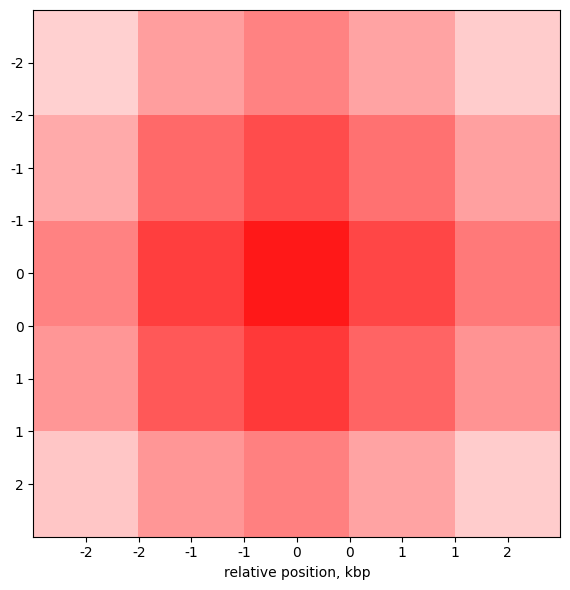

In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Global Values ──────────────────────────────────────────────────────────────────

# Window size NB this is also the minimal distance between CARs that will be considered
# If you consider too many low strength CARs that may be a problem
RESOLUTION  = 1000
FLANK       = 2_000 
ROOT        = "/home/nicolas/Documents/Workspace/nucleo/"


# ── Reading ──────────────────────────────────────────────────────────────────

clr = cooler.Cooler(
    ROOT +  "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

df_CARs_NN = pd.read_parquet(
    ROOT + "notebooks/cars/df_CARs_NN.parquet"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

pup = cpp_pileup(
    clr,
    df_CARs_NN,
    features_format="bedpe",
    flank=FLANK,
    view_df=view_df,
    expected_df=cvd,
    expected_value_col="count.avg.smoothed",
    clr_weight_name=None,
    nproc=8,
)


# ── Plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
mtx=pup.loc[0, 'data']
im=ax.imshow(
    np.log2((mtx)),
    cmap='bwr',
    vmin=-1,
    vmax=1,
interpolation='none')

ticks_pixels = np.linspace(0, FLANK*2//RESOLUTION,9)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*RESOLUTION//1000).astype(int)
ax.set(
    xticks=ticks_pixels,
    xticklabels=ticks_kbp,
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    xlabel='relative position, kbp'
    )
        
fig.tight_layout()


# ── Print ──────────────────────────────────────────────────────────────────

display(cvd.head())
print(clr.bins().columns)
print(df_CARs_NN.head())

# Nucleosomes

In [7]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
from pathlib import Path
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NN = pl.read_parquet("df_CARs_NN.parquet")

# Nucleosomes
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_NUCLEOSOMES = pl.read_csv(
    root,
    separator="\t"
)


# ── Analysis ──────────────────────────────────────────────────────────────────

# Adding New Columns
df_CARs_NUCLEO = df_CARs_NN.with_columns(
    pl.lit(None).alias("smt_pos"),
    pl.lit(None).alias("smt_value"),
    pl.lit(None).alias("fuzziness_score"),
    pl.lit(None).alias("NRLs")
)

# DataFrame Only With Positions for Filter
df_POS = df_NUCLEOSOMES.with_columns(
    pl.col("smt_pos").cast(pl.Float64)
)

# Adding a CAR Index
if "car_idx" not in df_CARs_NUCLEO.columns:
    df_CARs_NUCLEO = df_CARs_NUCLEO.with_row_index("car_idx")

# Filters
# joined a maintenant : car_idx, chrom1, start1, start2,
# + TOUTES les colonnes de df_NUCLEOSOMES (smt_pos, smt_value, fuzziness_score, etc.)
# → une ligne par (CAR, nucléosome) qui match
cars = df_CARs_NUCLEO.select(["car_idx", "chrom1", "start1", "start2"])
joined = cars.join_where(
    df_POS,
    pl.col("chr") == pl.col("chrom1"),
    pl.col("smt_pos") > pl.col("start1"),
    pl.col("smt_pos") < pl.col("start2"),
)


# ── Joining by CAR ──────────────────────────────────────────────

grouped = (
    joined
    .sort(["car_idx", "smt_pos"])
    .group_by("car_idx", maintain_order=True)
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
        pl.col("smt_pos").diff().slice(1).alias("NRLs"),
    )
)

# Fusion finale : on remplace les colonnes placeholders (None)
df_CARs_NUCLEO = (
    df_CARs_NUCLEO
    .drop(["smt_pos", "smt_value", "fuzziness_score", "NRLs"])
    .join(grouped, on="car_idx", how="left")
)


# ── Median Values ──────────────────────────────────────────────

df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    pl.col("smt_pos").fill_null([]),
    pl.col("smt_value").fill_null([]),
    pl.col("fuzziness_score").fill_null([]),
    pl.col("NRLs").fill_null([]),
).with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("start2") - pl.col("start1"))).alias("smt_density"),
)


# ── Save ──────────────────────────────────────────────────
print(df_CARs_NUCLEO)
df_CARs_NUCLEO.write_parquet("df_CARs_NUCLEO.parquet")

shape: (1_245, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28420.0  ┆ 28420.0  ┆ … ┆ 53.237259        ┆ 560.0      ┆ 14    ┆ 22.632613   │
│ 1       ┆ chrI   ┆ 30965.0  ┆ 30965.0  ┆ … ┆ 52.414125        ┆ 21840.0    ┆ 119   ┆ 129.195225  │
│ 2       ┆ chrI   ┆ 51741.0  ┆ 51741.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.171699  │
│ 3       ┆ chrI   ┆ 65253.0  ┆ 65253.0  ┆ … ┆ 55.314382        ┆ 17040.0    ┆ 52    ┆ 97.832523   │
│ 4       ┆ chrI   ┆ 74508.0  ┆ 74508.0  ┆ … ┆ 54.134448        ┆ 22720.

# Analysing by Categories

shape: (1_245, 18)
┌─────────┬────────┬──────────┬──────────┬───┬──────────────────┬────────────┬───────┬─────────────┐
│ car_idx ┆ chrom1 ┆ start1   ┆ end1     ┆ … ┆ fuzziness_median ┆ smt_median ┆ N_nuc ┆ smt_density │
│ ---     ┆ ---    ┆ ---      ┆ ---      ┆   ┆ ---              ┆ ---        ┆ ---   ┆ ---         │
│ u32     ┆ str    ┆ f64      ┆ f64      ┆   ┆ f64              ┆ f64        ┆ u32   ┆ f64         │
╞═════════╪════════╪══════════╪══════════╪═══╪══════════════════╪════════════╪═══════╪═════════════╡
│ 0       ┆ chrI   ┆ 28420.0  ┆ 28420.0  ┆ … ┆ 53.237259        ┆ 560.0      ┆ 14    ┆ 22.632613   │
│ 1       ┆ chrI   ┆ 30965.0  ┆ 30965.0  ┆ … ┆ 52.414125        ┆ 21840.0    ┆ 119   ┆ 129.195225  │
│ 2       ┆ chrI   ┆ 51741.0  ┆ 51741.0  ┆ … ┆ 50.88625         ┆ 24640.0    ┆ 78    ┆ 150.171699  │
│ 3       ┆ chrI   ┆ 65253.0  ┆ 65253.0  ┆ … ┆ 55.314382        ┆ 17040.0    ┆ 52    ┆ 97.832523   │
│ 4       ┆ chrI   ┆ 74508.0  ┆ 74508.0  ┆ … ┆ 54.134448        ┆ 22720.

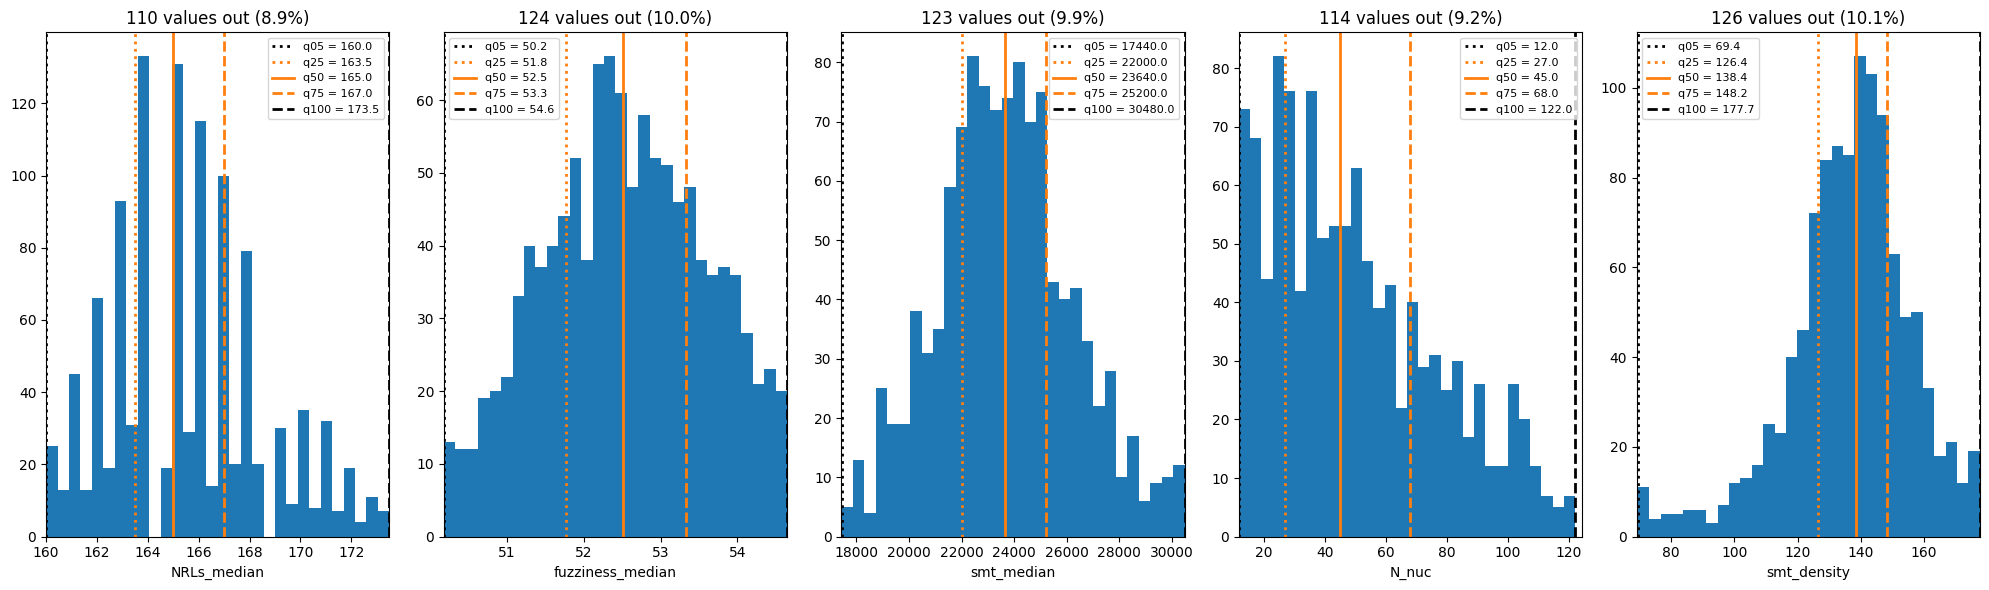

In [8]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# ── DataFrames ──────────────────────────────────────────────────────────────────

# CARs
df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")
print(df_CARs_NUCLEO)



# ── Prelimenary Analysis ──────────────────────────────────────────────────────

fig, axes = plt.subplots(figsize=(20, 6), ncols=5, nrows=1)

columns     = ["NRLs_median", "fuzziness_median", "smt_median", "N_nuc", "smt_density"]
quartiles   = []

for ax, col in zip(axes, columns):

    # Suppression des NaN / inf
    values = df_CARs_NUCLEO[col].to_numpy()
    values = values[np.isfinite(values)]

    # Conservation des 90 % centraux
    vmin, vmax = np.percentile(values, [5, 95])
    values_plot = values[(values >= vmin) & (values <= vmax)]

    n_removed = len(values) - len(values_plot)

    # Quartiles
    q25, q50, q75 = np.percentile(values_plot, [25, 50, 75])
    q05, q95 = np.min(values_plot), np.max(values_plot)
    quartiles.append({
        "value": col,
        "q05": q05,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "q95": q95,
    })

    # Histogramme
    ax.hist(values_plot, bins=30)
    ax.set_xlim(vmin, vmax)

    # Quartiles
    ax.axvline(q05, color="black", linestyle=":", linewidth=2, label=f"q05 = {q05:.1f}")
    ax.axvline(q25, color="tab:orange", linestyle=":", linewidth=2, label=f"q25 = {q25:.1f}")
    ax.axvline(q50, color="tab:orange", linestyle="-", linewidth=2, label=f"q50 = {q50:.1f}")
    ax.axvline(q75, color="tab:orange", linestyle="--", linewidth=2, label=f"q75 = {q75:.1f}")
    ax.axvline(q95, color="black", linestyle="--", linewidth=2, label=f"q100 = {q95:.1f}")

    # P
    ax.set_xlabel(col)
    ax.set_title(f"{n_removed} values out ({100*n_removed/len(values):.1f}%)")
    ax.legend(fontsize=8)

df_quartiles = pl.DataFrame(quartiles)
plt.tight_layout()
plt.show()

In [9]:
def filter_DataFrame_by_quartiles(
    df_data: pl.DataFrame, 
    df_quartiles: pl.DataFrame,
    value: str,
    quarter: int
) -> pl.DataFrame:
    
    # Security
    if value not in df_quartiles["value"].to_list():
        raise ValueError(f"You set value = {value} while it needs to be in {df_quartiles['value'].to_list()}")
    if quarter not in [1, 2, 3, 4]:
        raise ValueError(f"You set quarter = {quarter} while it needs to be in [1, 2, 3, 4]")
    
    # Selecting row (df_quartiles already shutted down below 5% and above 95%)
    row = df_quartiles.row(by_predicate=(pl.col("value") == value)) # Taking the row
    vmin, vmax = row[quarter], row[quarter+1]                       # Corresponding values

    # Filtering Values
    if quarter == 4:
        df_out = df_data.filter((pl.col(value) >= vmin) & (pl.col(value) <= vmax))
    else:
        df_out = df_data.filter((pl.col(value) >= vmin) & (pl.col(value) < vmax))

    return df_out


def get_quartile_bounds(df_quartiles: pl.DataFrame, value: str, quarter: int) -> tuple[float, float]:
    cols = ["q0", "q25", "q50", "q75", "q100"]
    row = df_quartiles.filter(pl.col("value") == value).row(0, named=True)
    vmin = row[cols[quarter - 1]]
    vmax = row[cols[quarter]]
    return vmin, vmax


filter_DataFrame_by_quartiles(
    df_data = df_CARs_NUCLEO,
    df_quartiles = df_quartiles,
    value = "N_nuc",
    quarter = 3
)

car_idx,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2,smt_pos,smt_value,fuzziness_score,NRLs,NRLs_median,fuzziness_median,smt_median,N_nuc,smt_density
u32,str,f64,f64,f64,str,f64,f64,f64,list[f64],list[f64],list[f64],list[f64],f64,f64,f64,u32,f64
3,"""chrI""",65253.0,65253.0,35.773094,"""chrI""",74508.0,74508.0,13.379583,"[65288.0, 65513.0, … 74410.0]","[30960.0, 27120.0, … 32400.0]","[55.175528, 54.158252, … 50.141691]","[225.0, 233.0, … 185.0]",162.0,55.314382,17040.0,52,97.832523
9,"""chrI""",137151.0,137151.0,34.139674,"""chrI""",147778.0,147778.0,179.868668,"[137240.0, 137421.0, … 147614.0]","[28240.0, 26080.0, … 38160.0]","[51.969889, 52.937233, … 52.610529]","[181.0, 157.0, … 195.0]",166.0,53.907634,26080.0,56,131.754964
31,"""chrII""",133696.0,133696.0,20.377044,"""chrII""",142201.0,142201.0,10.050608,"[133736.0, 133911.0, … 142027.0]","[23600.0, 6240.0, … 11040.0]","[49.304918, 64.614815, … 56.502826]","[175.0, 154.0, … 161.0]",165.0,55.86299,15800.0,50,95.586126
32,"""chrII""",142201.0,142201.0,10.050608,"""chrII""",150368.0,150368.0,58.067758,"[142234.0, 142352.0, … 150362.0]","[12080.0, 23440.0, … 21360.0]","[59.438898, 52.315317, … 56.428639]","[118.0, 158.0, … 157.0]",160.0,53.357094,22120.0,50,138.55761
33,"""chrII""",150368.0,150368.0,58.067758,"""chrII""",162373.0,162373.0,18.39124,"[150528.0, 150688.0, … 162247.0]","[32000.0, 22320.0, … 36160.0]","[51.440675, 54.633714, … 45.899538]","[160.0, 181.0, … 181.0]",167.0,51.5644,24960.0,67,149.151187
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1228,"""chrXVI""",796044.0,796044.0,37.741897,"""chrXVI""",804332.0,804332.0,55.026651,"[796094.0, 796273.0, … 804268.0]","[22640.0, 19040.0, … 34640.0]","[56.536426, 56.9328, … 54.445751]","[179.0, 181.0, … 226.0]",163.5,53.197058,23600.0,49,141.718147
1231,"""chrXVI""",815656.0,815656.0,13.202129,"""chrXVI""",824935.0,824935.0,30.168876,"[815668.0, 815821.0, … 824805.0]","[22960.0, 22160.0, … 29520.0]","[55.003081, 56.466777, … 51.962526]","[153.0, 164.0, … 156.0]",159.0,54.694563,19880.0,54,124.547904
1234,"""chrXVI""",835682.0,835682.0,24.798935,"""chrXVI""",850074.0,850074.0,11.624188,"[835812.0, 835960.0, … 847031.0]","[25600.0, 27680.0, … 3760.0]","[55.266768, 53.147694, … 50.944424]","[148.0, 189.0, … 125.0]",165.5,54.022554,19760.0,51,63.790995


# Quarters

In [10]:
# ── Checking the conservation of Data ──────────────────────────────────────────────────────────────────
QUARTERS  = [1, 2, 3, 4]
test_len  = 0

for q in QUARTERS:
    df_single = filter_DataFrame_by_quartiles(
        df_data = df_CARs_NUCLEO,
        df_quartiles = df_quartiles,
        value = "smt_median",
        quarter = q
    )

    test_len += len(df_single)

print(test_len + 100)

1217


# Distances génomiques entre CARs & Signal Cohésine

In [18]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pyBigWig


# ── DataFrame ──────────────────────────────────────────────────────────────────

if "df_CARs_NUCLEO" not in dir():
    df_CARs_NUCLEO = pl.read_parquet("df_CARs_NUCLEO.parquet")


# ── Distance génomique entre CAR1 et CAR2 (couples NN) ──────────────────────
# Les CARs sont des positions ponctuelles (start == end), donc la distance
# génomique entre les deux CARs voisines d'un couple NN est simplement :

df_CARs_NUCLEO = df_CARs_NUCLEO.with_columns(
    (pl.col("start2") - pl.col("start1")).alias("genomic_distance")
)

df_CARs_NUCLEO.select(["car_idx", "chrom1", "start1", "start2", "genomic_distance"])

car_idx,chrom1,start1,start2,genomic_distance
u32,str,f64,f64,f64
0,"""chrI""",28420.0,30965.0,2545.0
1,"""chrI""",30965.0,51741.0,20776.0
2,"""chrI""",51741.0,65253.0,13512.0
3,"""chrI""",65253.0,74508.0,9255.0
4,"""chrI""",74508.0,80364.0,5856.0
…,…,…,…,…
1240,"""chrXVI""",893788.0,909641.0,15853.0
1241,"""chrXVI""",909641.0,917004.0,7363.0
1242,"""chrXVI""",917004.0,921110.0,4106.0


## Distribution des distances génomiques entre CARs voisines

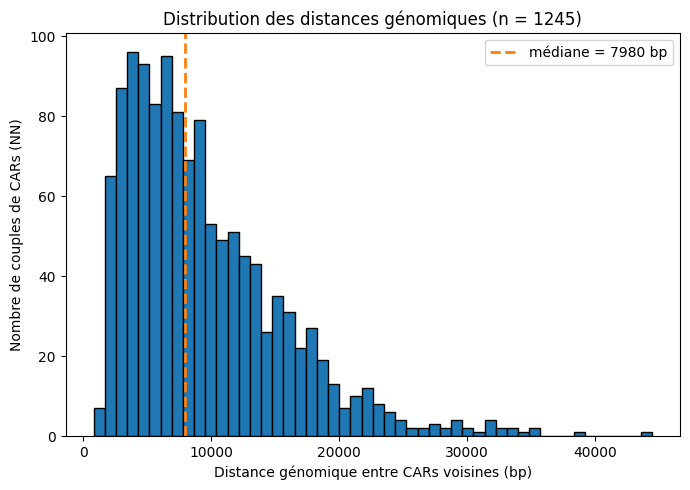

In [19]:
# ── Distribution des distances génomiques (couples NN) ──────────────────────

distances = df_CARs_NUCLEO["genomic_distance"].to_numpy()
distances = distances[np.isfinite(distances)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(distances, bins=50, color="tab:blue", edgecolor="black")

median_d = np.median(distances)
ax.axvline(median_d, color="tab:orange", linestyle="--", linewidth=2,
           label=f"médiane = {median_d:.0f} bp")

ax.set_xlabel("Distance génomique entre CARs voisines (bp)")
ax.set_ylabel("Nombre de couples de CARs (NN)")
ax.set_title(f"Distribution des distances génomiques (n = {len(distances)})")
ax.legend()

plt.tight_layout()
plt.show()


## Signal cohésine moyen ±1kb autour des CARs

In [20]:
# ── Signal cohésine moyen dans ±1kb autour de chaque CAR d'un couple NN ─────
# Hypothèse : signal = cohésine (Mcd1p, DATA_COHE), le même signal que celui
# utilisé pour détecter les CARs (cf. section "Enrichments").
# Pour chaque couple (CAR1, CAR2), on calcule le signal moyen autour de CAR1
# ET autour de CAR2, puis on prend la moyenne des deux comme valeur du couple.

FLANK_SIGNAL = 1_000  # ± 1 kb

bw = pyBigWig.open(DATA_COHE)

def mean_signal(chrom: str, center: float, flank: int = FLANK_SIGNAL) -> float:
    """Moyenne du signal bigwig dans la fenêtre [center-flank, center+flank]."""
    if chrom not in bw.chroms():
        return np.nan
    chrom_len = bw.chroms(chrom)
    start = max(0, int(center) - flank)
    end   = min(chrom_len, int(center) + flank)
    if end <= start:
        return np.nan
    val = bw.stats(chrom, start, end, type="mean")[0]
    return np.nan if val is None else val

pdf = df_CARs_NUCLEO.to_pandas()

pdf["cohesin_signal1"] = [
    mean_signal(c, p) for c, p in zip(pdf["chrom1"], pdf["start1"])
]
pdf["cohesin_signal2"] = [
    mean_signal(c, p) for c, p in zip(pdf["chrom2"], pdf["start2"])
]
pdf["cohesin_signal_mean"] = pdf[["cohesin_signal1", "cohesin_signal2"]].mean(axis=1)

bw.close()

df_CARs_NUCLEO = pl.from_pandas(pdf)
df_CARs_NUCLEO.select(
    ["car_idx", "genomic_distance", "cohesin_signal1", "cohesin_signal2", "cohesin_signal_mean"]
)


car_idx,genomic_distance,cohesin_signal1,cohesin_signal2,cohesin_signal_mean
u32,f64,f64,f64,f64
0,2545.0,12.580741,12.577189,12.578965
1,20776.0,12.577189,86.734577,49.655883
2,13512.0,86.734577,27.107771,56.921174
3,9255.0,27.107771,12.121241,19.614506
4,5856.0,12.121241,76.818678,44.46996
…,…,…,…,…
1240,15853.0,25.605746,17.942205,21.773975
1241,7363.0,17.942205,40.668046,29.305125
1242,4106.0,40.668046,9.513628,25.090837


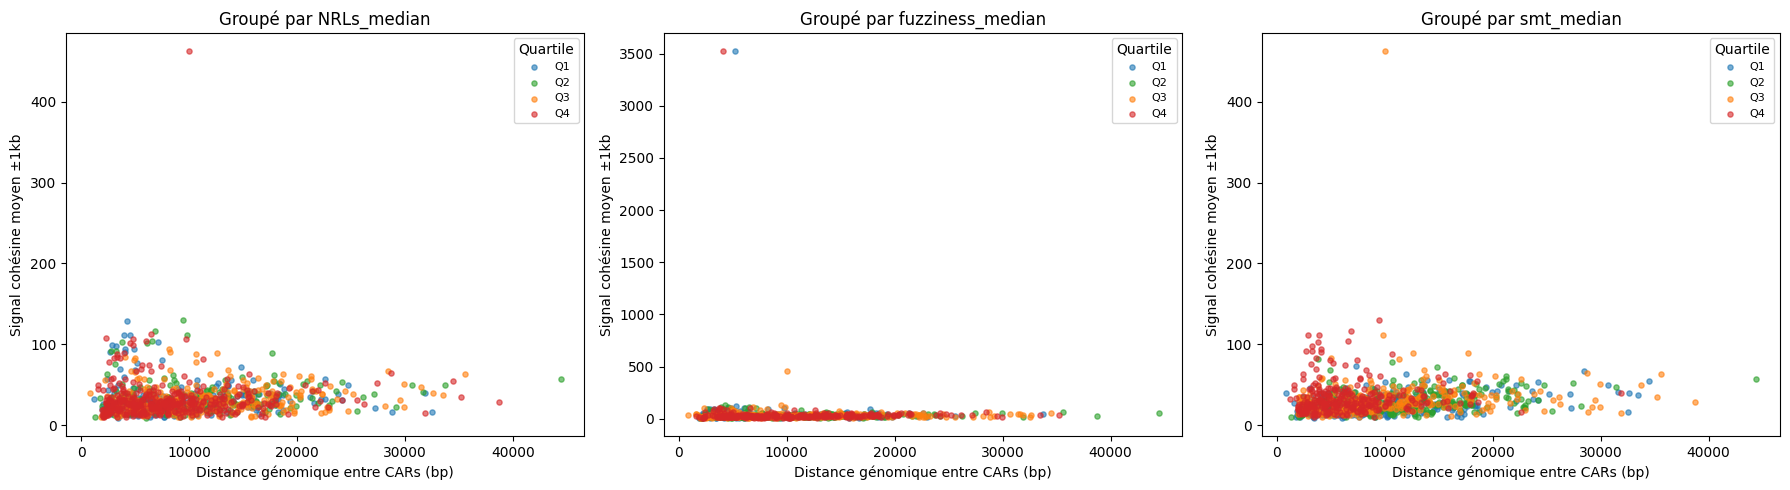

In [22]:
## Signal cohésine (±1kb) en fonction de la distance génomique, par groupe (NRLs / fuzziness / smt)
# ── Scatter plots : signal cohésine vs distance génomique, par groupe ───────
# Réutilise df_quartiles et filter_DataFrame_by_quartiles définis plus haut
# (section "Analysing by Categories") pour colorer chaque couple NN selon son
# quartile de NRLs_median / fuzziness_median / smt_median.

VALUES_GROUP = ["NRLs_median", "fuzziness_median", "smt_median"]
QUARTERS     = [1, 2, 3, 4]
COLORS       = {1: "tab:blue", 2: "tab:green", 3: "tab:orange", 4: "tab:red"}

fig, axes = plt.subplots(figsize=(6 * len(VALUES_GROUP), 5), ncols=len(VALUES_GROUP), nrows=1)

for ax, value in zip(axes, VALUES_GROUP):
    for q in QUARTERS:
        df_single = filter_DataFrame_by_quartiles(
            df_data=df_CARs_NUCLEO,
            df_quartiles=df_quartiles,
            value=value,
            quarter=q,
        )

        x = df_single["genomic_distance"].to_numpy()
        y = df_single["cohesin_signal_mean"].to_numpy()

        mask = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[mask], y[mask], s=14, alpha=0.6, color=COLORS[q], label=f"Q{q}")

    ax.set_xlabel("Distance génomique entre CARs (bp)")
    ax.set_ylabel("Signal cohésine moyen ±1kb")
    ax.set_title(f"Groupé par {value}")
    ax.legend(title="Quartile", fontsize=8)

plt.tight_layout()
plt.show()

## Hic Maps sur les NNCARs

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrIII', 'chrIII'): 2
INFO:coolpuppy:('chrI', 'chrI'): 1
INFO:coolpuppy:('chrVIII', 'chrVIII'): 6
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:coolpuppy:('chrIX', 'chrIX'): 4
INFO:coolpuppy:('chrX', 'chrX'): 5
INFO:coolpuppy:('chrXIII', 'chrXIII'): 3
INFO:coolpuppy:('chrVII', 'chrVII'): 4
INFO:coolpuppy:('chrXII', 'chrXII'): 5
INFO:coolpuppy:('chrXV', 'chrXV'): 3
INFO:coolpuppy:('chrXVI', 'chrXVI'): 7
INFO:coolpuppy:('chrXIV', 'chrXIV'): 4
INFO:coolpuppy:('chrXI', 'chrXI'): 2
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrIV', 'chrIV'): 8
INFO:coolpuppy:Total number of piled up windows: 61
INFO:coolpuppy:('chrI', 'chrI'): 2
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrIII', 'chrIII'): 2
INFO:coolpuppy:('chrIX', 'chrIX'): 3
INFO:coolpuppy:('chrXI', 'chrXI'): 9
INFO:coolpuppy:('chrX', 'chrX'): 7
INFO:coolpuppy:('chrVIII', 'chrVIII'): 3
INFO:coolpuppy:('chrXII', 'chrXII'): 6
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:co

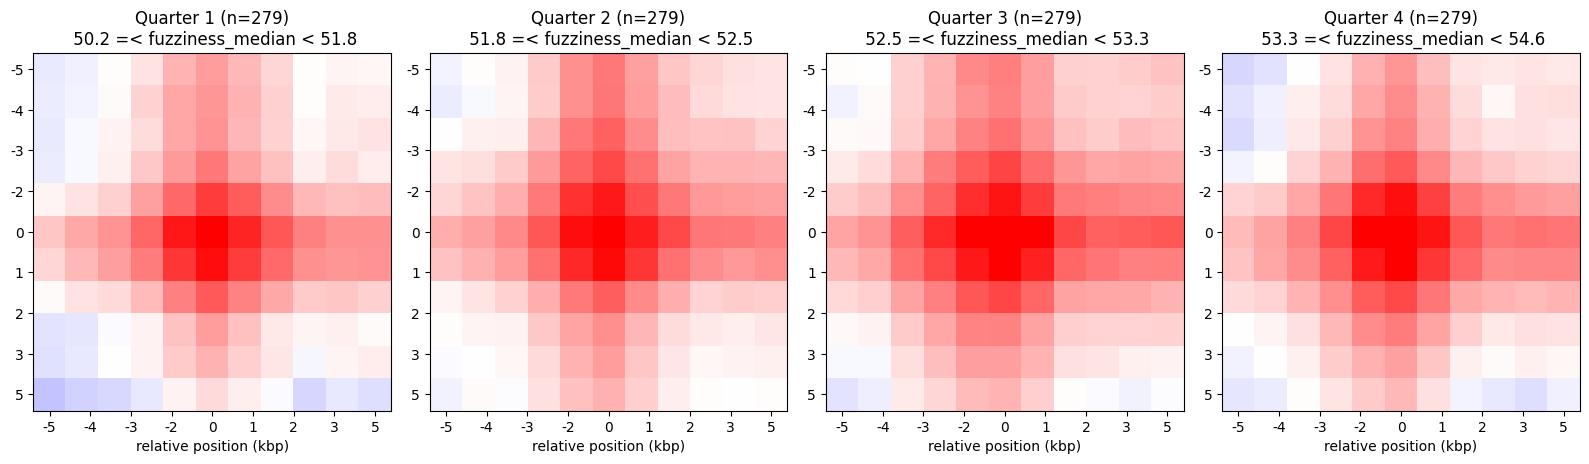

In [14]:
 # ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Préparation commune (ne dépend pas du quartile) ──────────────────────────
RESOLUTION  = 1000
FLANK       = 5_000 
ROOT        = "/home/nicolas/Documents/Workspace/nucleo/"


QUARTERS = [1, 2, 3, 4]
VALUE    =  "fuzziness_median"   #"N_nuc"


clr = cooler.Cooler(
    ROOT +  "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

# ── Calls for plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(figsize=(16, 6), ncols=len(QUARTERS), nrows=1)

for axi, quarter in zip(axes, QUARTERS):
    df_single = filter_DataFrame_by_quartiles(
        df_data=df_CARs_NUCLEO,
        df_quartiles=df_quartiles,
        value=VALUE,
        quarter=quarter,
    ).to_pandas()

    vmin = np.min(df_single[VALUE].to_numpy())
    vmax = np.max(df_single[VALUE].to_numpy())

    pup = cpp_pileup(
        clr,
        df_single,
        features_format="bedpe",
        flank=FLANK,
        view_df=view_df,
        expected_df=cvd,
        expected_value_col="count.avg.smoothed",
        clr_weight_name=None,
        nproc=8,
    )

    # ── Plot sur le sous-graphique correspondant ─────────────────────────────
    mtx = pup.loc[0, 'data']
    im = axi.imshow(
        np.log2(mtx),
        cmap='bwr',
        vmin=-1,
        vmax=1,
        interpolation='none'
    )

    ticks_pixels = np.linspace(0, FLANK * 2 // RESOLUTION, 9)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * RESOLUTION // 1000).astype(int)
    axi.set(
        xticks=ticks_pixels,
        xticklabels=ticks_kbp,
        yticks=ticks_pixels,
        yticklabels=ticks_kbp,
        xlabel='relative position (kbp)',
        title=(
            f"Quarter {quarter} (n={len(df_single)})\n"
            f" {vmin:.1f} =< {VALUE} < {vmax:.1f}"
        ),
    )

plt.tight_layout()
plt.show()

INFO:root:creating a Pool of 8 workers
INFO:coolpuppy:('chrI', 'chrI'): 2
INFO:coolpuppy:('chrIX', 'chrIX'): 2
INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrVI', 'chrVI'): 1
INFO:coolpuppy:('chrVIII', 'chrVIII'): 2
INFO:coolpuppy:('chrX', 'chrX'): 7
INFO:coolpuppy:('chrV', 'chrV'): 3
INFO:coolpuppy:('chrXI', 'chrXI'): 5
INFO:coolpuppy:('chrXII', 'chrXII'): 6
INFO:coolpuppy:('chrXIV', 'chrXIV'): 5
INFO:coolpuppy:('chrXVI', 'chrXVI'): 6
INFO:coolpuppy:('chrII', 'chrII'): 4
INFO:coolpuppy:('chrXV', 'chrXV'): 4
INFO:coolpuppy:('chrIV', 'chrIV'): 11
INFO:coolpuppy:('chrXIII', 'chrXIII'): 2
INFO:coolpuppy:('chrVII', 'chrVII'): 10
INFO:coolpuppy:Total number of piled up windows: 71
INFO:coolpuppy:('chrI', 'chrI'): 1
INFO:coolpuppy:('chrV', 'chrV'): 2
INFO:coolpuppy:('chrIII', 'chrIII'): 1
INFO:coolpuppy:('chrX', 'chrX'): 2
INFO:coolpuppy:('chrIX', 'chrIX'): 3
INFO:coolpuppy:('chrVIII', 'chrVIII'): 4
INFO:coolpuppy:('chrVII', 'chrVII'): 12
INFO:coolpuppy:('chrXIII', 'chrXIII'): 5


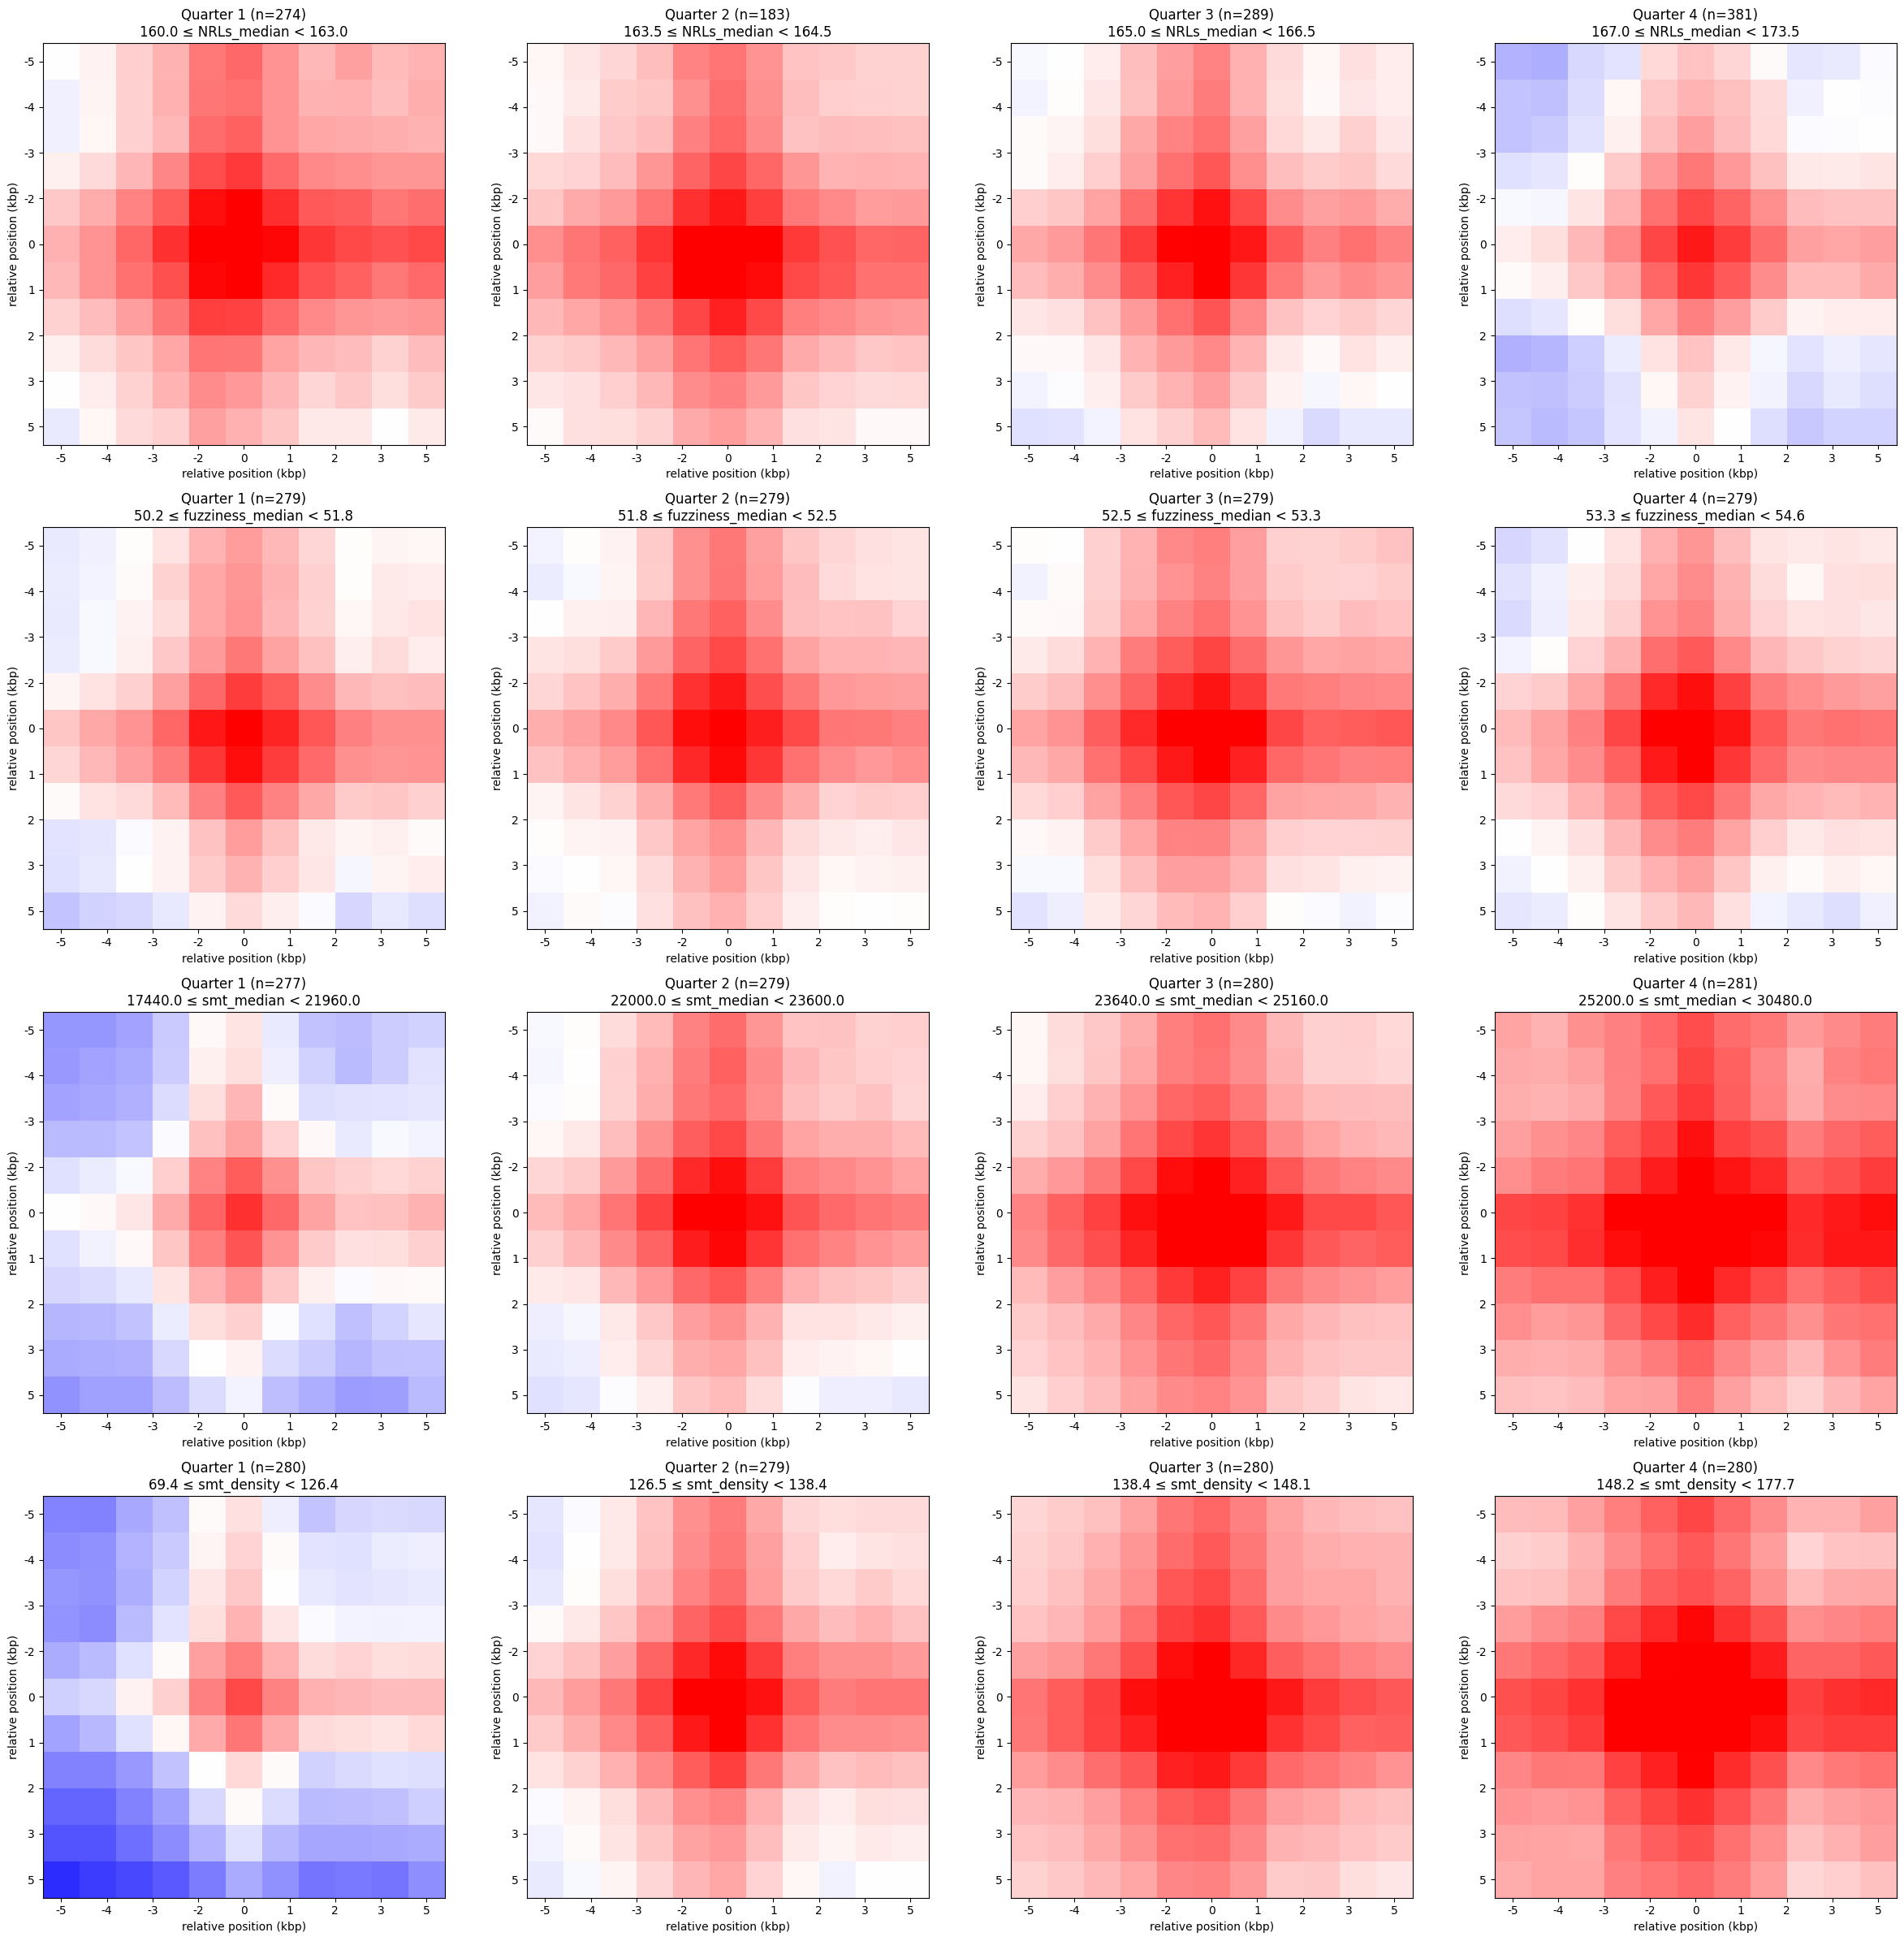

In [15]:
# ── Imports ──────────────────────────────────────────────────────────────────

# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bio
import cooler
import cooltools
from coolpuppy.coolpup import pileup as cpp_pileup


# ── Parameters ───────────────────────────────────────────────────────────────

RESOLUTION = 1000
FLANK      = 5_000
ROOT       = "/home/nicolas/Documents/Workspace/nucleo/"

QUARTERS = [1, 2, 3, 4]
VALUES   = ["NRLs_median", "fuzziness_median", "smt_median", "smt_density"]

nrows = len(VALUES)
ncols = len(QUARTERS)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 6 * nrows),
    squeeze=False
)


# ── Calculation ───────────────────────────────────────────────────────────────

clr = cooler.Cooler(
    ROOT + "outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)


# ── Calls for plots ──────────────────────────────────────────────────────────

for i, value in enumerate(VALUES):
    for j, quarter in enumerate(QUARTERS):

        axi = axes[i, j]

        df_single = filter_DataFrame_by_quartiles(
            df_data=df_CARs_NUCLEO,
            df_quartiles=df_quartiles,
            value=value,
            quarter=quarter,
        ).to_pandas()

        vmin = df_single[value].min()
        vmax = df_single[value].max()

        pup = cpp_pileup(
            clr,
            df_single,
            features_format="bedpe",
            flank=FLANK,
            view_df=view_df,
            expected_df=cvd,
            expected_value_col="count.avg.smoothed",
            clr_weight_name=None,
            nproc=8,
        )

        mtx = pup.loc[0, "data"]

        im = axi.imshow(
            np.log2(mtx),
            cmap="bwr",
            vmin=-1,
            vmax=1,
            interpolation="none",
        )

        ticks_pixels = np.linspace(0, FLANK * 2 // RESOLUTION, 9)
        ticks_kbp = (
            (ticks_pixels - ticks_pixels[-1] / 2) * RESOLUTION // 1000
        ).astype(int)

        axi.set(
            xticks=ticks_pixels,
            xticklabels=ticks_kbp,
            yticks=ticks_pixels,
            yticklabels=ticks_kbp,
            xlabel="relative position (kbp)",
            ylabel="relative position (kbp)",
            title=(
                f"Quarter {quarter} (n={len(df_single)})\n"
                f"{vmin:.1f} ≤ {value} < {vmax:.1f}"
            ),
        )

plt.tight_layout()
plt.show()

# HiC Map

/tmp/ipykernel_27153/3395831196.py:4: RuntimeWarning: divide by zero encountered in log2
  np.log2(mtx_2),


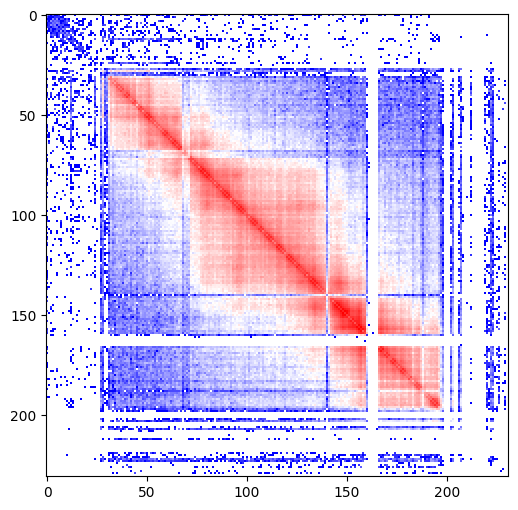

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx_2=clr.matrix(balance=False).fetch("chrI")
im=ax.imshow(
    np.log2(mtx_2),
    cmap='bwr',
    # vmin=-1,
    # vmax=1,
interpolation='none')

# .